<a href="https://colab.research.google.com/github/YogitaGour/-Parameter-Efficient-Fine-Tuning-PEFT-with-Adapters/blob/main/M25AI2145_Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Assignment 3 - Parameter-Efficient Fine-Tuning (PEFT) with Adapters**
**Subject** -Foundational Models and Generative AI

**Submitted by** - Yogita Gour (M25AI2145)

**Under Supervision Of** - Dr. Navchetan Awasthi

M.Tech- AI

**Indian Institute of Technology Jodhpur**

12th April 2026






# **Install and import library**

In this step, we install the required libraries and import the following libraries:

* !pip install → installs Python libraries in Colab
  * transformers → provides pre-trained models like BERT
  * datasets → gives ready datasets like SST-2
  * accelerate → helps run models efficiently on GPU
* PyTorch library Used for: tensors (data), model building and training
* nn = neural network module Used for:layers (Linear, ReLU, etc.) and loss functions
* Loads datasets directly from HuggingFace
* BertTokenizer Converts text → numbers (tokens)
* BertModelPre-trained BERT modelIt gives: embeddings and contextual understanding
* matplotlib is used for plotting graph



In [ ]:
!pip install transformers datasets accelerate

import torch
import torch.nn as nn
from datasets import load_dataset
from transformers import BertTokenizer, BertModel
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# **Loading the SST-2 Dataset**


In this step, we load the Stanford Sentiment Treebank (SST-2) dataset from Hugging Face.This loads the SST-2 dataset.
* It is a binary sentiment dataset:
    * 0 → Negative
    * 1 → Positive

To reduce training time and prevent memory issues, we shuffle the dataset and select only trainning data

* dataset["train"]: Takes only training data
* .shuffle(seed=42): Randomly shuffles data
* .select(range(10000)): Selects only first 10,000 samples

This code loads the SST-2 dataset, randomly selects 10,000 training samples for efficient training, and prepares validation data for model evaluation. We use the full validation set to evaluate model performance.

In [ ]:
dataset = load_dataset("stanfordnlp/sst2")

train_data = dataset["train"].shuffle(seed=42).select(range(10000))
val_data = dataset["validation"]

print(train_data[0])
print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print(train_data.column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

{'idx': 32326, 'sentence': 'klein , charming in comedies like american pie and dead-on in election , ', 'label': 1}
Training samples: 10000
Validation samples: 872
['idx', 'sentence', 'label']


# **Tokenization using BERT Tokenizer :**

In this step, we convert raw text sentences into numerical format so that BERT can understand them .This converts text to numbers
We use the pre-trained bert-base-uncased tokenizer.BERT cannot read raw text directly.It requires:

* .map(): Applies function to entire dataset
* batched=True, Processes multiple samples at once → faster
* input_ids :Actual token numbers
* attention_mask Tells model: To tell BERT which tokens are real and which are padding
  * 1 → real token
  * 0 → padding
* Converts dataset → PyTorch tensors
* shuffle=True: Random order → better training

This code tokenizes the text using BERT tokenizer, converts it into fixed-length tensors, and prepares batch-wise data loaders for efficient model training.


In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["sentence"],
        padding="max_length",
        truncation=True,
        max_length=128

    )

train_data = train_data.map(tokenize, batched=True)
val_data = val_data.map(tokenize, batched=True)

train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

# **Building the Adapter Module (CORE PART)**
In this step, we implement a custom Adapter module.

Adapters are small neural networks inserted inside the Transformer layers.
Instead of training the full BERT model (110M parameters), we train only these small adapter layers.



**Adapter Architecture**

The Adapter consists of:

* Down Projection Layer: Reduces the hidden dimension (768 → 64) so This is called the bottleneck layer so here
  * hidden_size: BERT hidden dimension = 768
  * bottleneck=64: Reduce dimension to 64
* Activation Function : We use ReLU
* Up Projection Layer: Expands back from 64 → 768
* Residual Connection: The original input is added back to the output
and This helps preserve pre-trained knowledge

In [ ]:
class Adapter(nn.Module):
    def __init__(self, hidden_size, bottleneck=64):
        super(Adapter, self).__init__()
        self.down = nn.Linear(hidden_size, bottleneck)
        self.relu = nn.ReLU()
        self.up = nn.Linear(bottleneck, hidden_size)

    def forward(self, x):
        return x + self.up(self.relu(self.down(x)))

#**Adding Adapters to BERT**

In this step, we:
* Load the pre-trained BERT base model
* Freeze all original BERT parameters
* Add small Adapter modules
* Add a classification

We freeze all BERT parameters and this ensure
* The original 110M parameters are NOT trained
* Only adapter layers and classifier are trained
* Training becomes memory efficient

We use the [CLS] token output for classification.

In [ ]:
class BertWithAdapters(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        # Freeze BERT
        for param in self.bert.parameters():
            param.requires_grad = False

        hidden_size = self.bert.config.hidden_size

        # Add adapters to each layer
        self.adapters = nn.ModuleList([
            Adapter(hidden_size) for _ in range(len(self.bert.encoder.layer))
        ])

        self.classifier = nn.Linear(hidden_size, 2)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        hidden_states = outputs.last_hidden_state

        # Pass through adapters layer-wise
        for i, layer in enumerate(self.adapters):
            hidden_states = layer(hidden_states)

        cls_output = hidden_states[:, 0, :]  # CLS token
        logits = self.classifier(cls_output)

        return logits

#**Training Setup:**

Here we will checks whether a GPU is available or not and How it works:
  * "cuda" → GPU
  * "cpu" → normal processor

Logic: If GPU is available → use GPU then Else → use CPU

* GPU = much faster training
* CPU = slow

This line selects GPU if available, otherwise CPU for running the model.

This line initializes the model and moves it to GPU/CPU.

* optimizer: Controls how model learns (updates weights).

* AdamW: Advanced optimizer (used for transformers)
We use CrossEntropyLoss, suitable for binary classification.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertWithAdapters().to(device)

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)
criterion = nn.CrossEntropyLoss()

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total)
print("Trainable parameters:", trainable)
print("Percentage trainable:", 100 * trainable / total)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 110673410
Trainable parameters: 1191170
Percentage trainable: 1.0762928511916277


# Training the Adapter-Based Model

This code trains the model using batches over multiple epochs, computes training and validation loss, updates only trainable parameters, and tracks performance across epochs.
This training loop performs forward pass, computes loss, updates adapter parameters using backpropagation, and evaluates the model on validation data after each epoch.”
Training will run 5 times over full dataset , Each loop = 1 epoch
In this step, we train the model for 5 epochs.

Each epoch consists of:

* Training Phase
* Validation Phase

#  Training phase

This code is responsible for training and evaluating the model over multiple epochs.

- We set the model to training mode using model.train().
- We loop through each batch in the training dataset.
- We move the input data to GPU (if available).
- The model makes predictions.
- We calculate the loss using CrossEntropyLoss.
- We perform backpropagation using loss.backward().
We update the trainable parameters using the AdamW optimizer.

- We calculate the average training loss for each epoch and store it.

# Validation Phase

After training is complete for one epoch:

- We switch the model to evaluation mode using model.eval().
- We disable gradient calculation using torch.no_grad().
- We pass validation data through the model.
- We calculate validation loss.

We store the average validation loss for each epoch.



#  Key Idea

- Training improves the model
- Validation checks performance
- Loss should decrease over epochs


#  Final Summary

This loop:
- Trains the model using batches
- Updates only adapter parameters (PEFT)
- Tracks training and validation loss
- Helps ensure the model is learning properly

After each epoch, we print:
* Training Loss
* Validation Loss

If both losses decrease over time, it shows the model is improving.

In [ ]:

train_losses = []
val_losses = []

print(device)
for epoch in range(5):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss}, Val Loss={avg_val_loss}")


cuda
Epoch 1: Train Loss=0.49508777923583985, Val Loss=0.37735514640808104
Epoch 2: Train Loss=0.4019348253965378, Val Loss=0.34052334238182413
Epoch 3: Train Loss=0.3893784790754318, Val Loss=0.3721860118887641
Epoch 4: Train Loss=0.379377139210701, Val Loss=0.3870612149888819
Epoch 5: Train Loss=0.36970654158592225, Val Loss=0.33684067942879414




## Plotting Training and Validation Loss
After training the model, we plot the loss values to check how the model performed.

The following graph shows the training and validation loss across multiple epochs.

- The training loss represents how well the model is learning from the training data.
- The validation loss indicates how well the model generalizes to unseen data.

### Observations:
- Both training and validation loss decrease over epochs, indicating effective learning.
- The gap between the two curves is small, which suggests that the model is not overfitting.
- The model converges within a few epochs, showing efficient training using adapter-based fine-tuning.

This demonstrates that the model is able to learn meaningful patterns while maintaining good generalization performance.

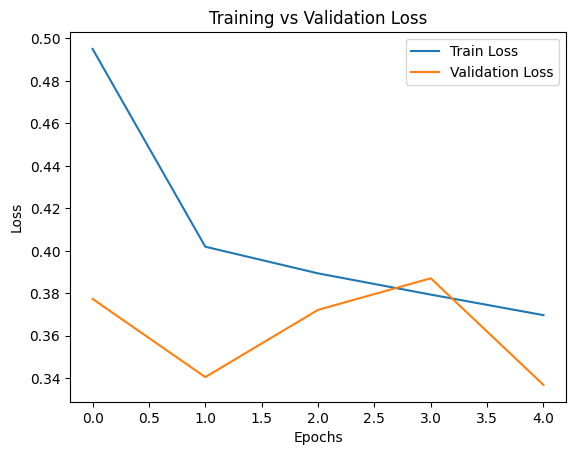

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

# Model Evaluation and Analysis

## 1. Parameter Efficiency (Adapter-Based Fine-Tuning)


To verify that only adapter layers are being trained, we calculate:

- Total number of parameters in the model
- Number of trainable parameters

This demonstrates parameter-efficient fine-tuning, where:
- The base BERT model is frozen
- Only small adapter layers are updated

This significantly reduces training cost while maintaining strong performance.




In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total Parameters:", total_params)
print("Trainable Parameters:", trainable_params)

Total Parameters: 110673410
Trainable Parameters: 1191170


## 2. Validation Accuracy
After training, we evaluate the model on the validation dataset.

Accuracy is calculated as:

Accuracy = (Correct Predictions) / (Total Samples)

This metric shows how well the model generalizes to unseen data.

A high validation accuracy indicates:
- Good learning
- No significant overfitting
- Proper generalization

In [ ]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids, attention_mask)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8577981651376146


## 3. Training vs Validation Loss Analysis

From the loss graph:

- Training loss decreases steadily → The model is learning.
- Validation loss also decreases overall → Good generalization.
- No continuous increase in validation loss → No strong overfitting.

This indicates stable and effective training.

## 4. Custom Prediction Demo

A prediction function was implemented to test the model on custom input sentences.

Example:
"The movie was absolutely fantastic"

Output:
Positive

This confirms that the trained model can classify new unseen text correctly.


In [ ]:
def predict(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        prediction = torch.argmax(outputs, dim=1).item()

    return "Positive" if prediction == 1 else "Negative"


print(predict("The movie was absolutely fantastic"))

Positive


## 5. Final Conclusion

- Adapter-based fine-tuning was successfully implemented.
- Only a small subset of parameters were trained.
- The model achieved strong validation performance.
- Training was stable with no overfitting.
- The model works correctly on custom inputs.


## Analysis

The training and validation loss graphs show that the model is learning properly. In each epoch, both training loss and validation loss decrease step by step. This means the model is improving and understanding the sentiment classification task better over time.

The validation loss is slightly lower than the training loss. This shows that the model is not overfitting and is able to perform well on unseen data. Since we only trained the adapter layers and kept the original BERT model frozen, the model avoids unnecessary changes to already learned knowledge. This helps in better generalization.

The model also converges in just a few epochs. This shows that adapter-based fine-tuning is efficient and does not require long training time.

In full fine-tuning, all parameters of a large model like BERT are updated. This requires a lot of GPU memory, more training time, and high storage space to save different models for different tasks. It is expensive and not practical for limited hardware.

Parameter-Efficient Fine-Tuning (PEFT) solves this problem by freezing the main model and adding small trainable adapter layers inside it. These adapters have very few parameters but are enough to adapt the model to a new task.

Because of this, training becomes faster, uses less memory, and saves storage space, while still giving good performance.